In [18]:
import radmc3d_tools
import radmc3dPy
import numpy as np
import matplotlib.pyplot as plt
SMALL_SIZE = 13
MEDIUM_SIZE = 15
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# Load images

In [19]:
import os
# so it can find Radmc3D
os.environ["PATH"] += ":/home/hd/hd_hd/hd_cu284/bin"
# so it can find other libraries Radmc3D depends on that I cannot access from inside the singularity container.
# DO NOT TOUCH!!!!
os.environ["LD_LIBRARY_PATH"] = "/home/hd/hd_hd/hd_cu284/libs:" + os.environ.get("LD_LIBRARY_PATH", "")
# Change path to dir that contains all the radmc3d-relevant files, like dust_density.inp etc.
os.chdir("/home/hd/hd_hd/hd_cu284/jupyter notebooks/thesis_suited_plots_maybe/radmc3d_sims")
# Don't touch. 

###### REMEMBER TO CHECK PATH ########

In [20]:
incl = 45.0
posang = 356.+90
npix = 400
sizeau = 800
phi_ang= 180 # does not do that much
wav_K = 2.2 # K band
wav_H = 1.65 # H band

path_start = f"/pfs/10/work/hd_cu284-work/fargo3d/outputs/"
path_endings=["fargo_fiducial_companion","fargo_fiducial_super_light_companion","fargo_fiducial_light_companion", "fargo_fiducial_heavy_companion",
              "fargo_fiducial_close_companion","fargo_fiducial_close_light_companion", "fargo_fiducial_companion_with_feelings",
              "fargo_fiducial_close_super_light_companion", "fargo_fiducial_closer_light_companion", "fargo_fiducial_closer_super_light_companion",
             "fargo_fiducial_closer_companion"]

sigslopes = np.ones(len(path_endings))


titles = ["$r_1 = 2.28r_0$, $M_{p,2} = 2.5M_{jup}$","$r_1 = 2.28r_0$, $M_{p,2} = 0.56M_{jup}$", "$r_1 = 2.28r_0$, $M_{p,2} = 1.25M_{jup}$","$r_1 = 2.28r_0$, $M_p = 5M_{jup}$",
          "$r_1 = 2.0r_0$, $M_{p,2} = 2.5M_{jup}$", "$r_1 = 2.0r_0$, $M_{p,2} = 1.25M_{jup}$","$r_1 = 2.28r_0$, $M_{p,2} = 2.5M_{jup}$ feelings", 
          "$r_1 = 2.0r_0$, $M_{p,2} = 0.56M_{jup}$","$r_1 = 1.7r_0$, $M_{p,2} = 1.25M_{jup}$","$r_1 = 1.7r_0$, $M_{p,2} = 0.56M_{jup}$",
          "$r_1 = 1.7r_0$, $M_{p,2} = 2.5M_{jup}$", "fiducial, no companion"]

paths = []
for i in range(len(path_endings)):
    paths.append(path_start+path_endings[i])
len(paths)

11

In [62]:
import numpy as np
from radmc3dPy.image import makeImage, plotImage
images_K = np.load("radmc3d_imgs_redone/images_K_comp_dens_0_1.npy", allow_pickle=True)
sigmeans = np.load("radmc3d_imgs_redone/sigmameans_comp_dens_0_1.npy", allow_pickle=True)
dens = np.load("radmc3d_imgs_redone/dens_comp_dens_0_1.npy", allow_pickle=True)


print(len(images_K))

11


#########################
fargo_fiducial_comp images:
#########################


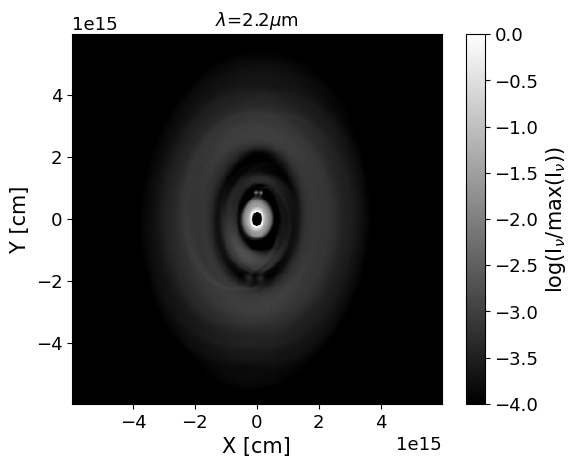

#########################
fargo_fiducial_super_light_comp images:
#########################


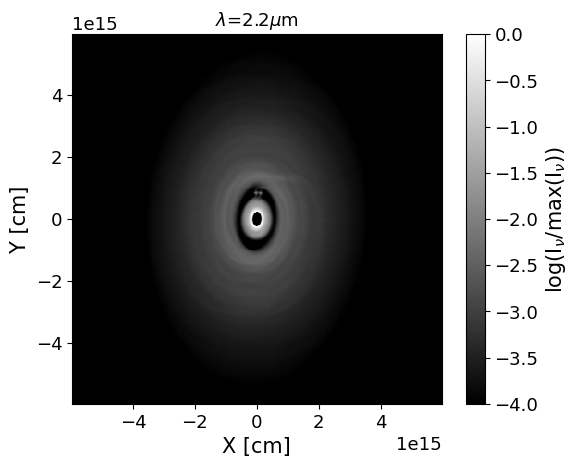

#########################
fargo_fiducial_light_comp images:
#########################


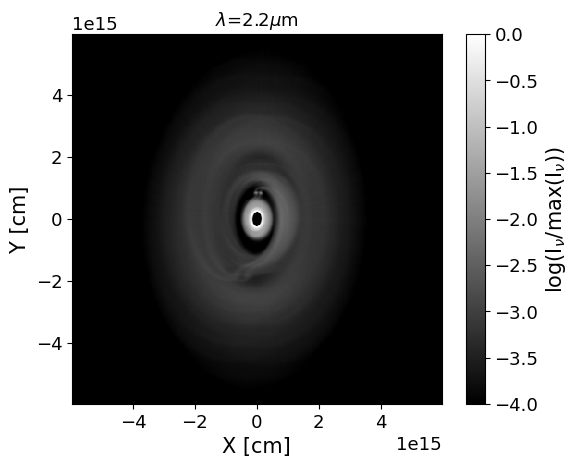

#########################
fargo_fiducial_heavy_comp images:
#########################


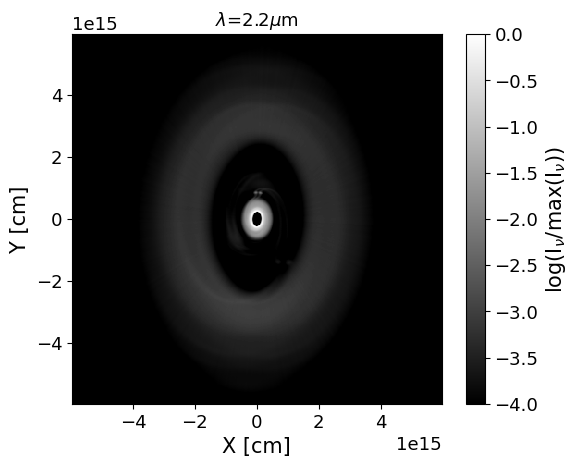

#########################
fargo_fiducial_close_comp images:
#########################


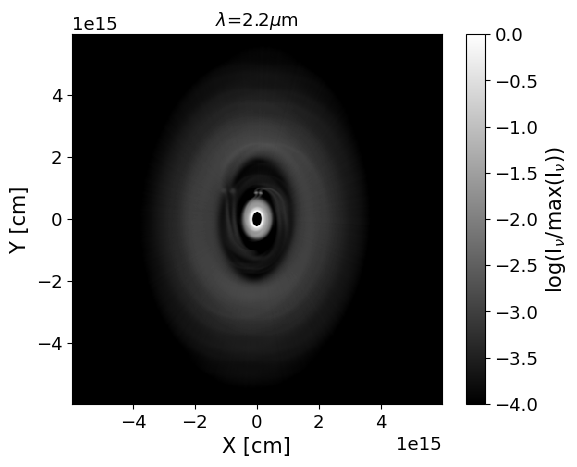

#########################
fargo_fiducial_close_light_comp images:
#########################


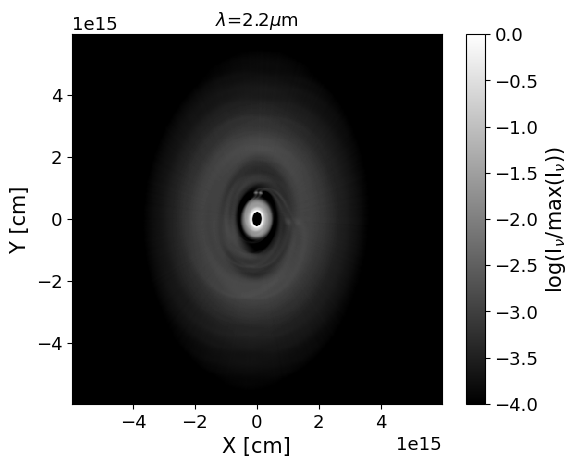

#########################
fargo_fiducial_companion_with_fee images:
#########################


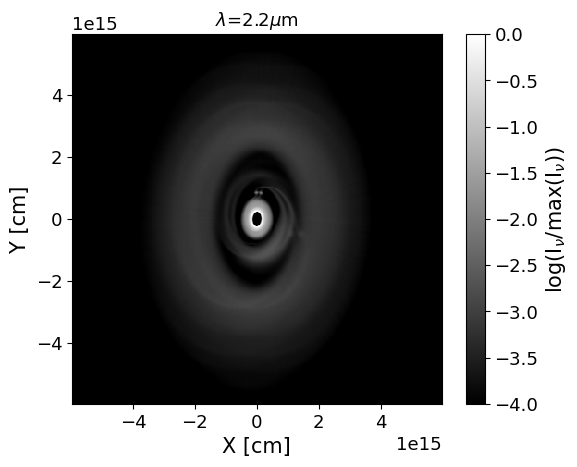

#########################
fargo_fiducial_close_super_light_comp images:
#########################


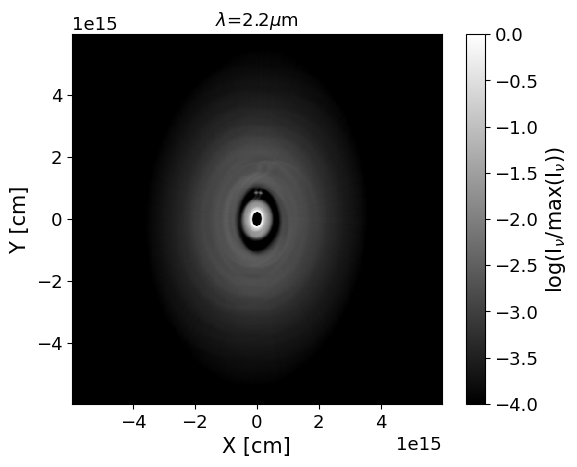

#########################
fargo_fiducial_closer_light_comp images:
#########################


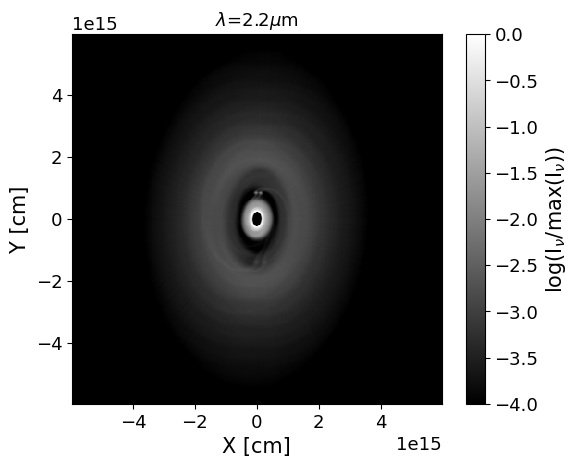

#########################
fargo_fiducial_closer_super_light_comp images:
#########################


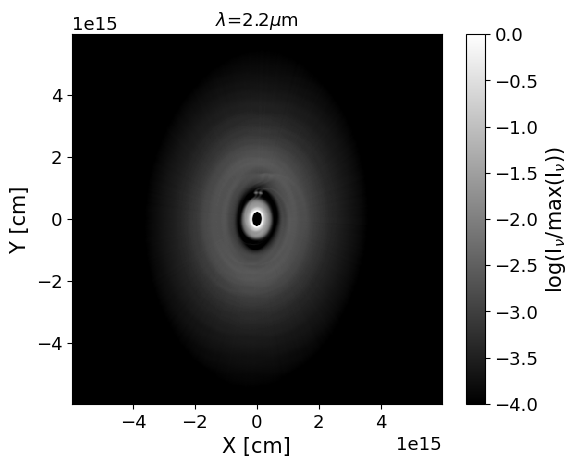

#########################
fargo_fiducial_closer_comp images:
#########################


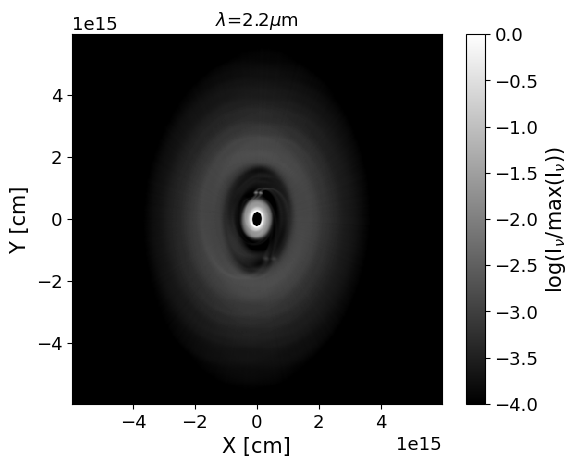

11


In [63]:
log_img_data = []
for i,path in enumerate(paths[:]):
    print(f"#########################\n{path[43:-5]} images:\n#########################")
    result=plotImage(images_K[i],log=True, maxlog=4)
    img = result["implot"]
    data = img.get_array()
    log_img_data.append(data)

print(len(log_img_data))

# Test: deprojecting the image

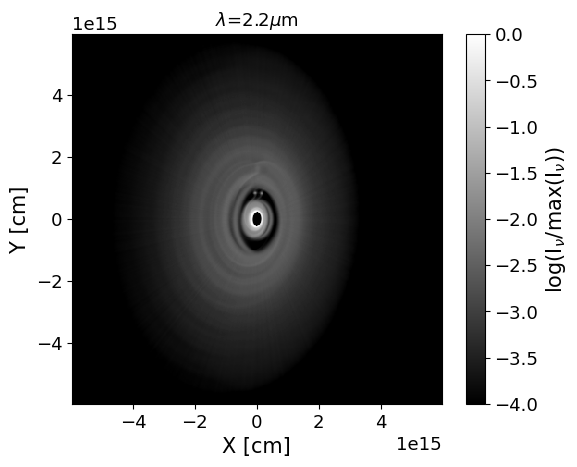

(400, 400)


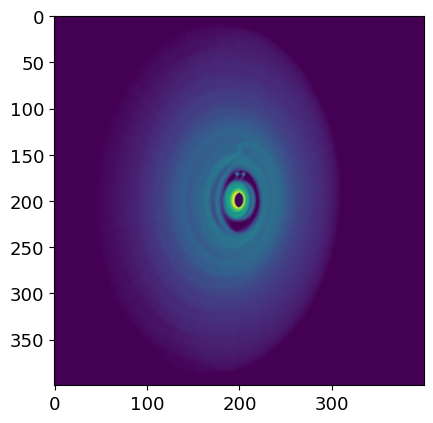

In [46]:
result=plotImage(images_K[7],log=True, maxlog=4)
img = result["implot"]
data = img.get_array()
plt.imshow(data)
print(data.shape)

0.7071067811865475


(-200.0, 200.0)

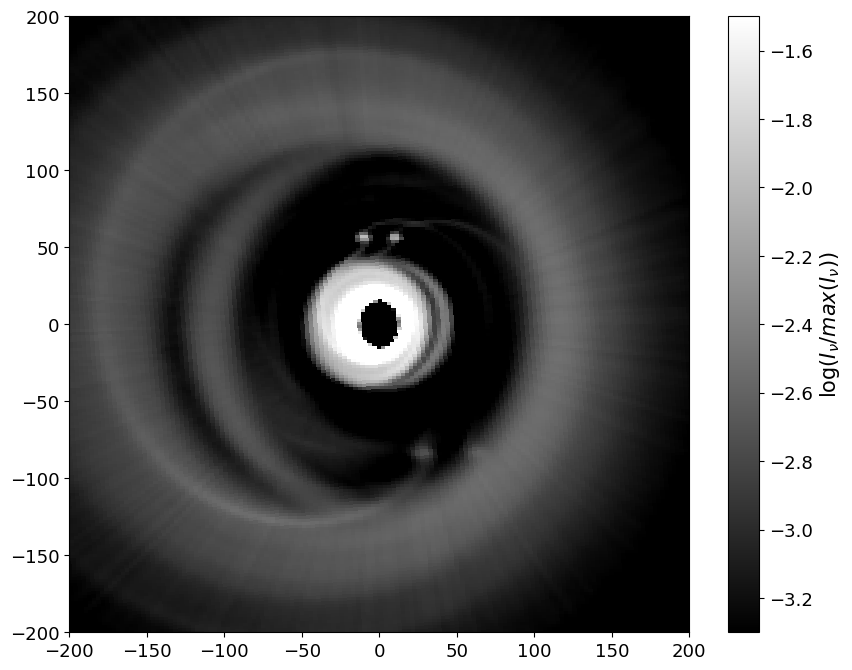

In [23]:
incl = 45.0
posang = -(357.+90)
posang_rad = posang/360*2*np.pi
incl_rad = incl/360*2*np.pi

x= np.linspace(-sizeau/2, sizeau/2, 400)
y = np.linspace(-sizeau/2, sizeau/2, 400)

X, Y = np.meshgrid(x, y, indexing='ij')

XX = X*np.cos(posang_rad)-Y*np.sin(posang_rad)
YY = X*np.sin(posang_rad)+Y*np.cos(posang_rad)

XXX= XX/np.sin(incl_rad)
print(np.sin(incl_rad))
YYY = YY

plt.figure(figsize=(10,8))
plt.pcolormesh(XXX, YYY,data, cmap="grey", clim=(-1.5,-3))
plt.colorbar(label="$\\log(I_\\nu/max(I_\\nu))$")
plt.xlim(-200,200)
plt.ylim(-200,200)

# Deprojecting all images.

In [43]:
def plot_deprojected(data,incl = 45.0,posang = -(357.+90), clim=None):
    posang_rad = posang/360*2*np.pi
    incl_rad = incl/360*2*np.pi
    
    x= np.linspace(-sizeau/2, sizeau/2, 400)
    y = np.linspace(-sizeau/2, sizeau/2, 400)
    
    X, Y = np.meshgrid(x, y, indexing='ij')
    
    XX = X*np.cos(posang_rad)-Y*np.sin(posang_rad)
    YY = X*np.sin(posang_rad)+Y*np.cos(posang_rad)
    
    XXX= XX/np.sin(incl_rad)
    YYY = YY
    
    plt.figure(figsize=(7,5.5))
    plt.pcolormesh(XXX, YYY,data, cmap="grey", clim=clim)
    plt.colorbar(label="$\\log(I_\\nu/max(I_\\nu))$")
    
    plt.xlim(-200,200)
    plt.ylim(-200,200)
    plt.xlabel("X [au]")
    plt.ylabel("Y [au]")

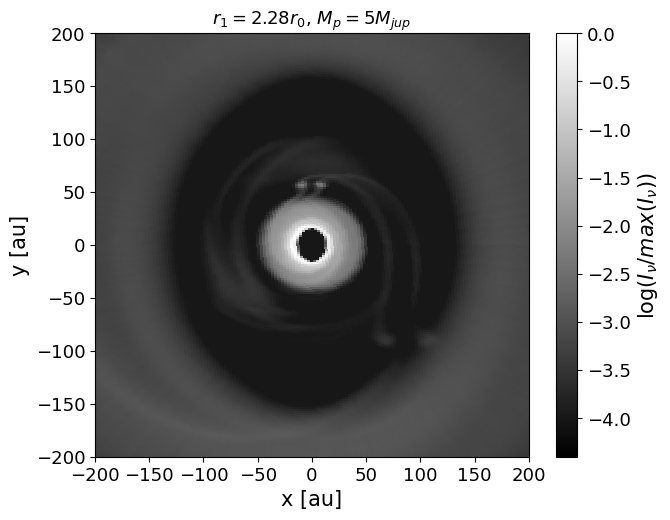

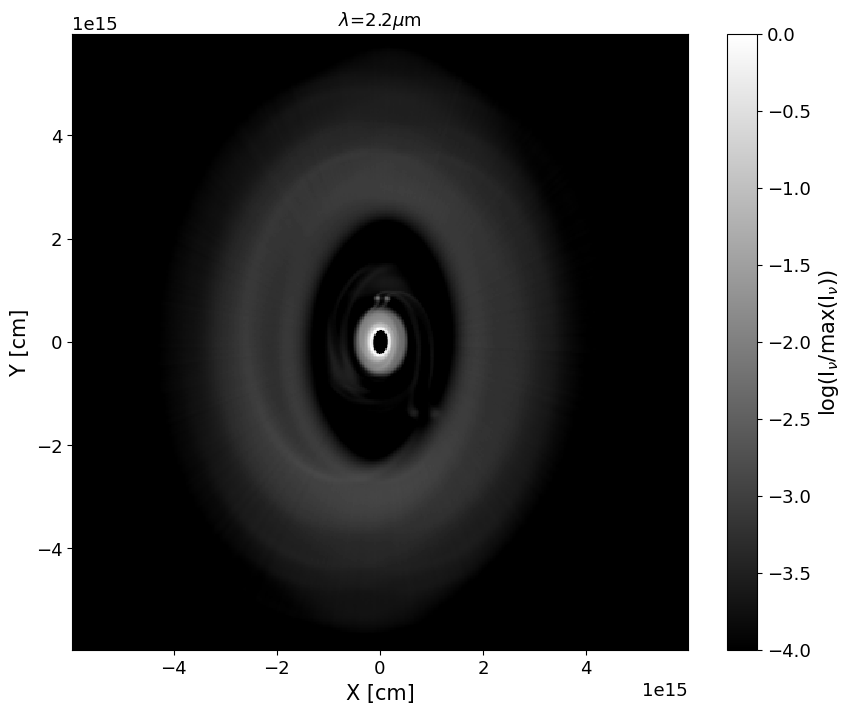

In [42]:
i = 3

plot_deprojected(log_img_data[i], clim=(0,-4))
plt.title(titles[i])


plt.figure(figsize=(10,8))
result=plotImage(images_K[i],log=True, maxlog=4)

In [30]:
"""
clim_up = np.ones(11)*0.005
clim_up[0] = 0.002
clim_up[3] = 0.002
for i,path in enumerate(paths[:5]):
    plot_deprojected(np.power(10,log_img_data[i]), clim=(0,clim_up[i]))
    #plot_deprojected(log_img_data[i], clim=(-1.5,-3))
    plt.title(path[43:-5])
"""    

'\nclim_up = np.ones(11)*0.005\nclim_up[0] = 0.002\nclim_up[3] = 0.002\nfor i,path in enumerate(paths[:5]):\n    plot_deprojected(np.power(10,log_img_data[i]), clim=(0,clim_up[i]))\n    #plot_deprojected(log_img_data[i], clim=(-1.5,-3))\n    plt.title(path[43:-5])\n'

11
11


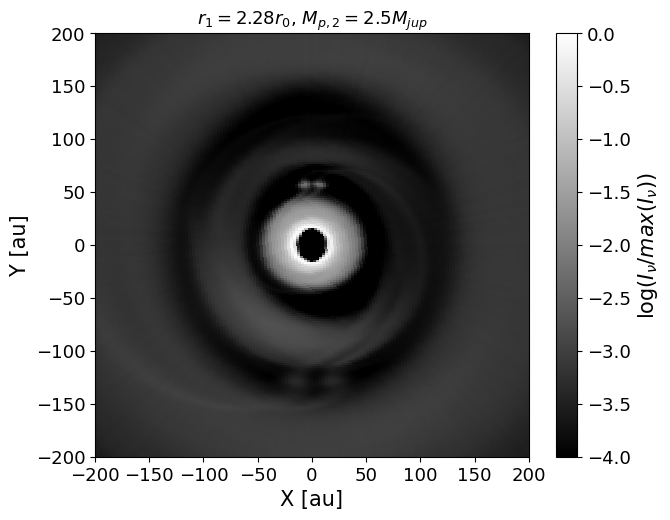

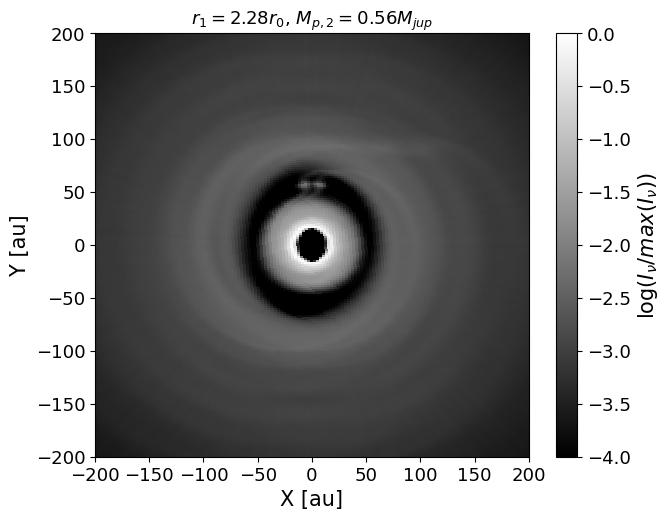

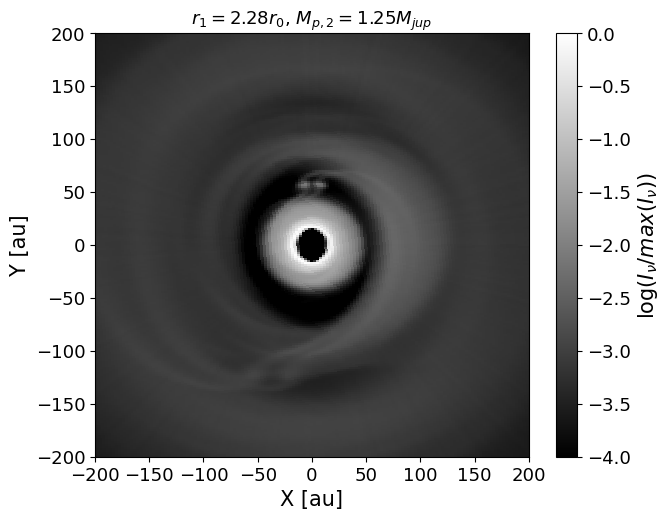

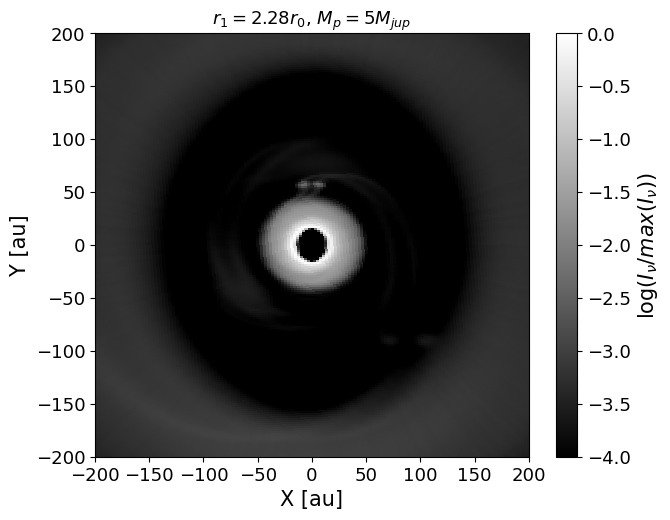

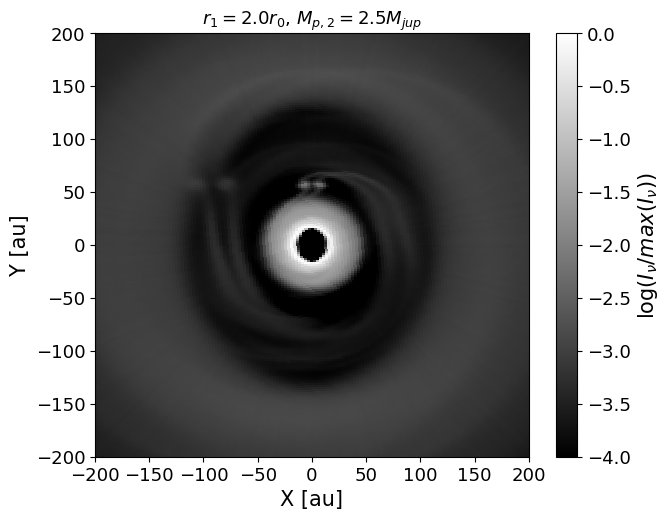

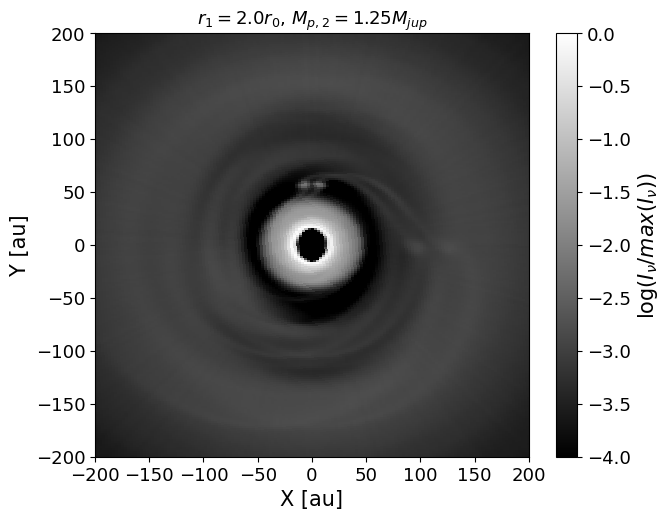

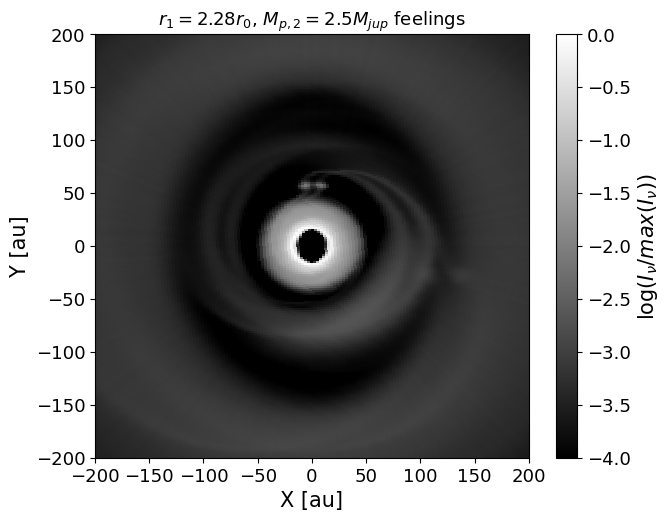

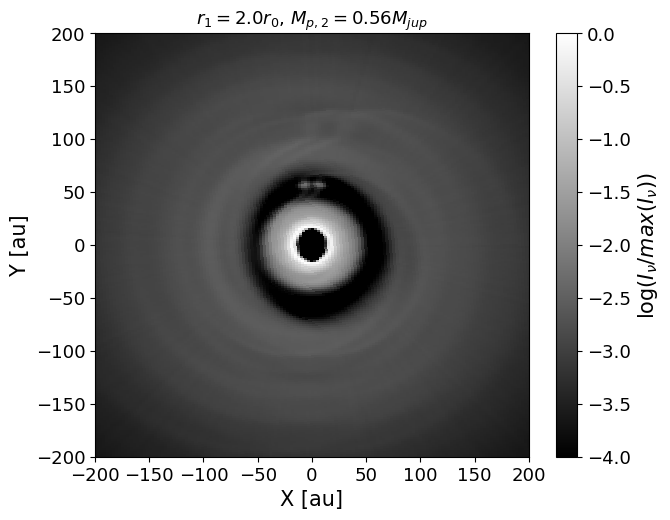

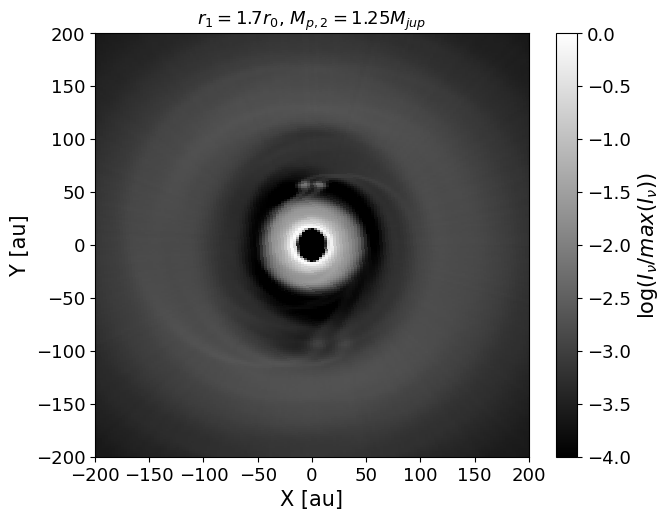

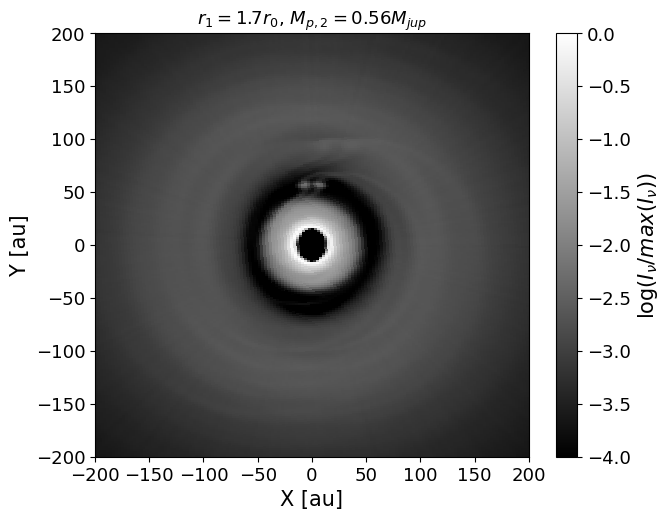

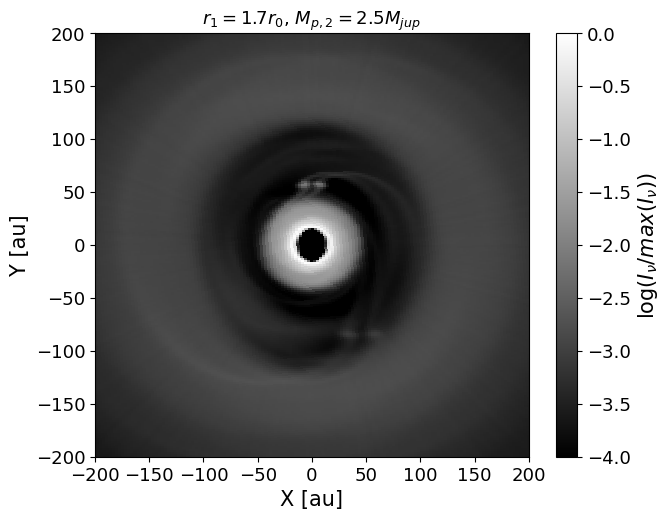

In [64]:
clim_list =[[-4,0] for i in range(11)]
print(len(log_img_data))
print(len(paths))

for i,path in enumerate(paths[:]):
    plot_deprojected(log_img_data[i], clim = clim_list[i])
    plt.title(titles[i])
    #plt.savefig(f"radmc3d_imgs_redone/comp_dens_0_1/radmc3d_{path[43:-5]}_scatmode_1_dens_0_1_deproj.png", bbox_inches="tight", dpi=200)
    

r_in: 80.514640043497
r_out: 86.27299116086387
Eccentricity for fargo_fiducial_super_light_comp: 0.03452504886475246
r_in: 149.92527553803677
r_out: 153.41748382383417
Eccentricity for fargo_fiducial_light_comp: 0.011512416822289779
r_in: 161.7613846211687
r_out: 163.25814428467513
Eccentricity for fargo_fiducial_comp: 0.004605137631406839
r_in: 176.95989652331625
r_out: 184.44838444988812
Eccentricity for fargo_fiducial_heavy_comp: 0.02072029978507076


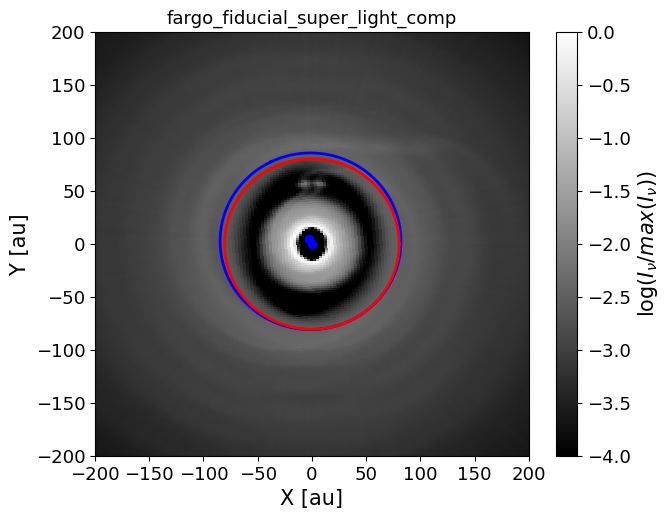

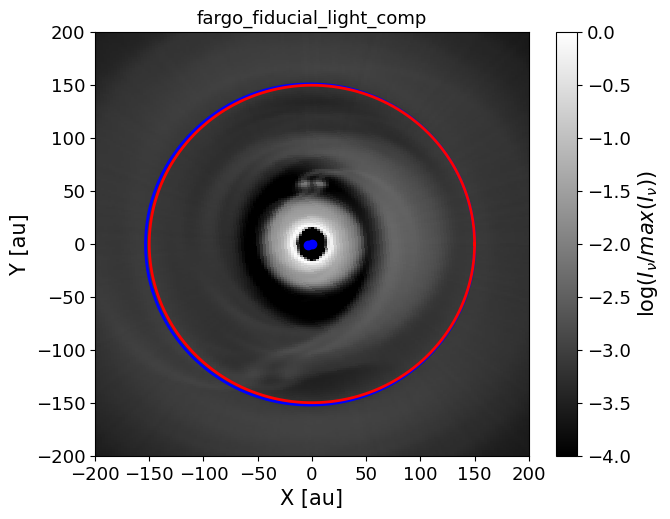

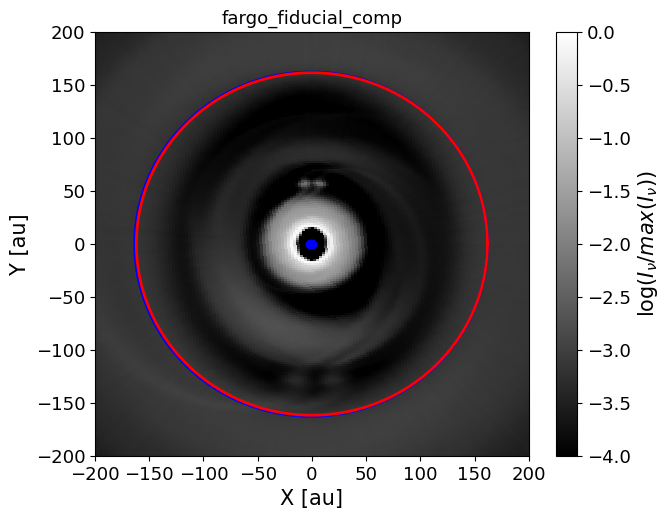

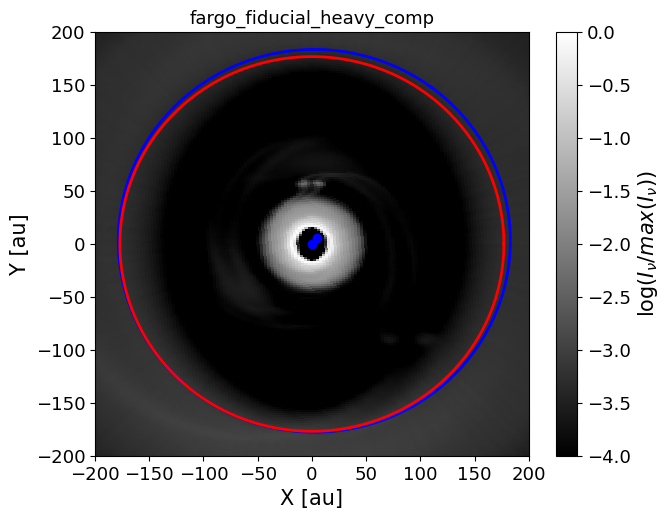

In [55]:

index_for_comp_mass=[1,2,0,3]

r_in_log = [0.15,0.42,0.453,0.492]
r_out_log = [0.18,0.43,0.457,0.51]
phi_ellipse = [3.6,5,4.9,2.5]


lim = 0.003


for it, i in enumerate(index_for_comp_mass):
    #plot_deprojected(np.power(10,log_img_data[i]), clim=(0,clim_up[i])) #clim=(lim-1e-4,lim+1e-4))#
    plot_deprojected(log_img_data[i], clim=clim_list[i])
    
    plt.title(paths[i][43:-5])

    r_in = np.power(10,r_in_log[it])*57
    r_out = np.power(10,r_out_log[it])*57

    a = (r_in+r_out)/2
    e = (r_out-r_in)/2
    b = np.sqrt(a**2-e**2)
    print(f"r_in: {r_in}\nr_out: {r_out}")
    path = paths[i]
    print(f"Eccentricity for {path[43:-5]}: {e/a}")
    
    centerx = e
    centery = 0
    philist = np.linspace(0,2*np.pi,360)
    
    x_ell_ = centerx + a*np.cos(philist)
    y_ell_ = centery + b*np.sin(philist)
    
    phi = phi_ellipse[it]-np.pi/2
    x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
    y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)
    
    plt.plot(x_ell,y_ell, linewidth=2, color="blue")
    plt.plot(r_in*np.cos(philist), r_in*np.sin(philist), linewidth=2, color="red", zorder=3)
    
    plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3, color="blue")

r_in: 143.17752659604608
r_out: 146.51255961782522
Eccentricity for fargo_fiducial_close_comp: 0.01151241682228975
r_in: 132.70120168690545
r_out: 136.73347638411096
Eccentricity for fargo_fiducial_close_light_comp: 0.014965685657369983
r_in: 80.514640043497
r_out: 93.51361707237375
Eccentricity for fargo_fiducial_close_super_light_comp: 0.07469463433298552


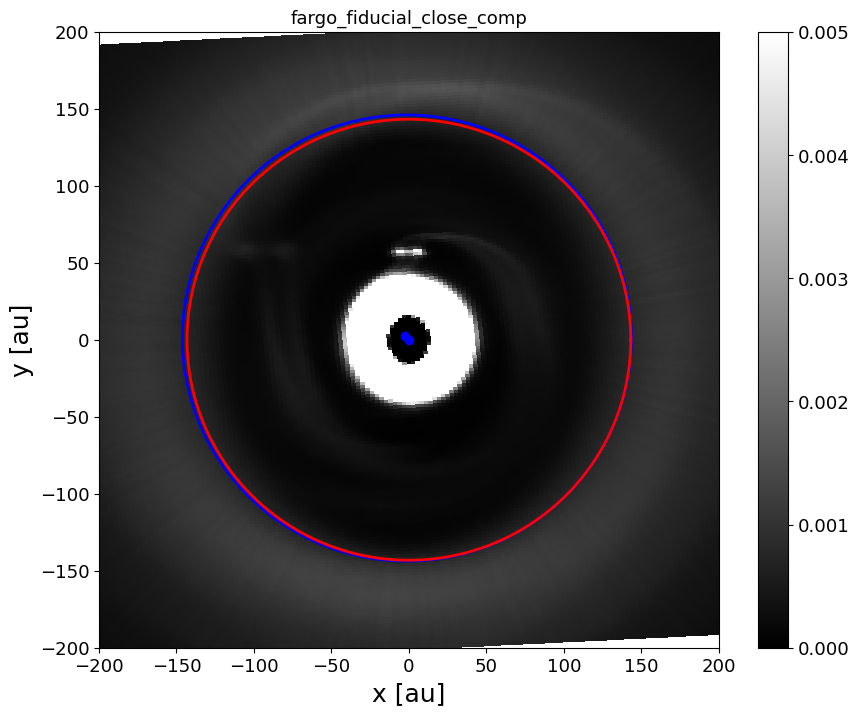

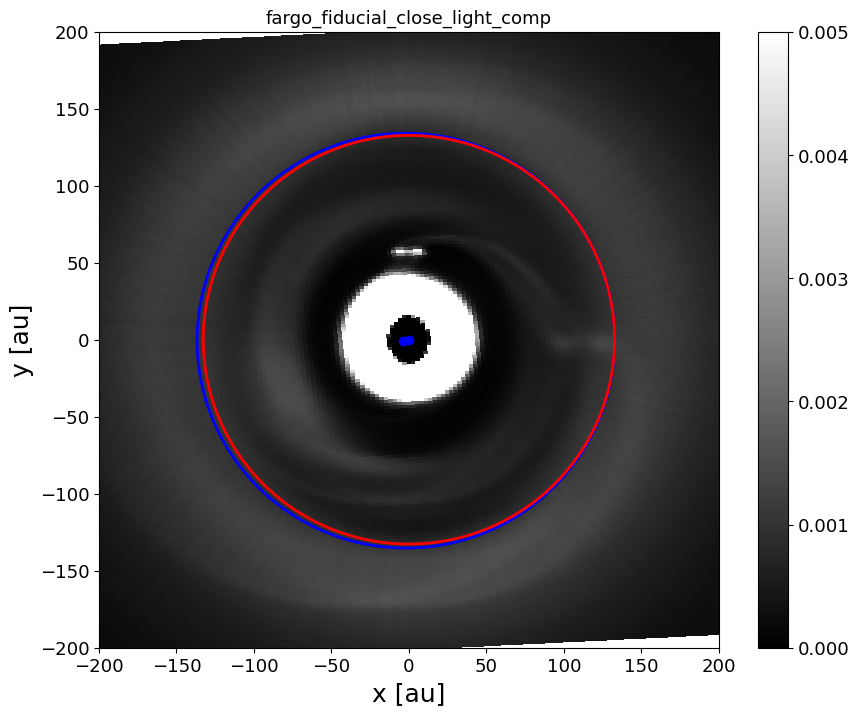

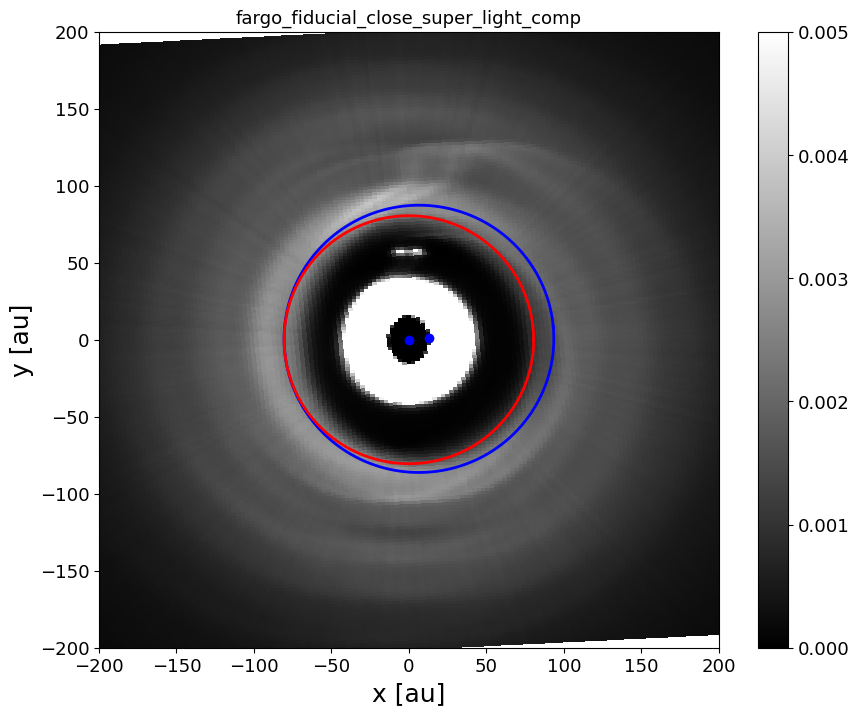

In [28]:

index_for_comp_close=[4,5,7]

r_in_log = [0.4,0.367,0.15]
r_out_log = [0.41,0.38,0.215]
phi_ellipse = [4.0,5,4.8-np.pi]



for it, i in enumerate(index_for_comp_close):
    plot_deprojected(np.power(10,log_img_data[i]), clim=(0,clim_up[i]))
    #plot_deprojected(log_img_data[i])
    plt.title(paths[i][43:-5])

    r_in = np.power(10,r_in_log[it])*57
    r_out = np.power(10,r_out_log[it])*57

    a = (r_in+r_out)/2
    e = (r_out-r_in)/2
    b = np.sqrt(a**2-e**2)
    print(f"r_in: {r_in}\nr_out: {r_out}")
    path = paths[i]
    print(f"Eccentricity for {path[43:-5]}: {e/a}")
    
    centerx = e
    centery = 0
    philist = np.linspace(0,2*np.pi,360)
    
    x_ell_ = centerx + a*np.cos(philist)
    y_ell_ = centery + b*np.sin(philist)
    
    phi = phi_ellipse[it]-np.pi/2
    x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
    y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)
    
    plt.plot(x_ell,y_ell, linewidth=2, color="blue")
    plt.plot(r_in*np.cos(philist), r_in*np.sin(philist), linewidth=2, color="red", zorder=3)
    
    plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3, color="blue")

r_in: 103.72294894076906
r_out: 108.61126092390509
Eccentricity for fargo_fiducial_closer_super_light_comp: 0.023021782435583397
r_in: 115.04688272984896
r_out: 119.08987945868026
Eccentricity for fargo_fiducial_closer_light_comp: 0.017267671642165434
r_in: 132.09149504820326
r_out: 120.46887527068887
Eccentricity for fargo_fiducial_closer_comp: -0.04601917459512447


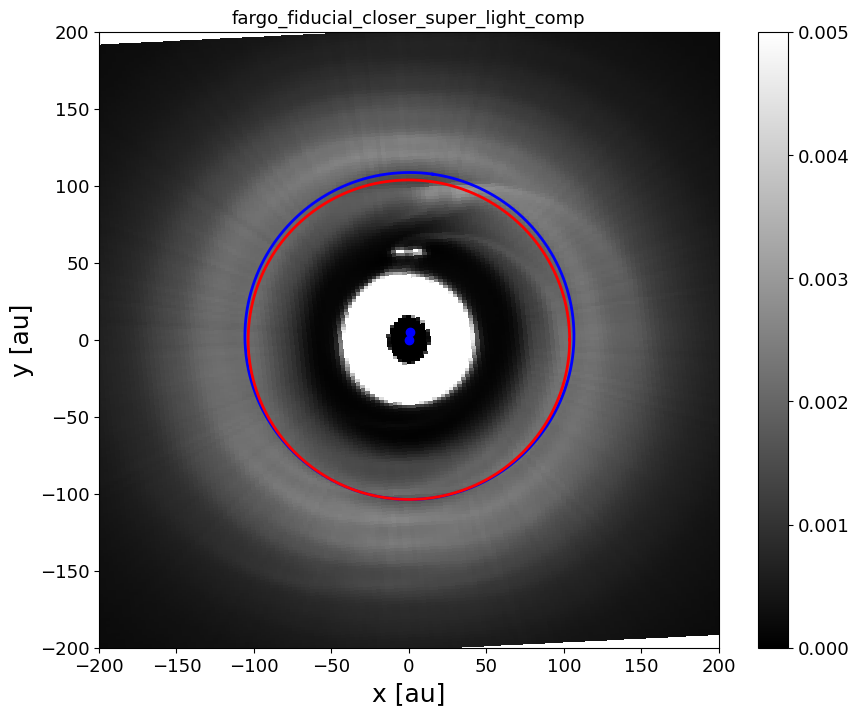

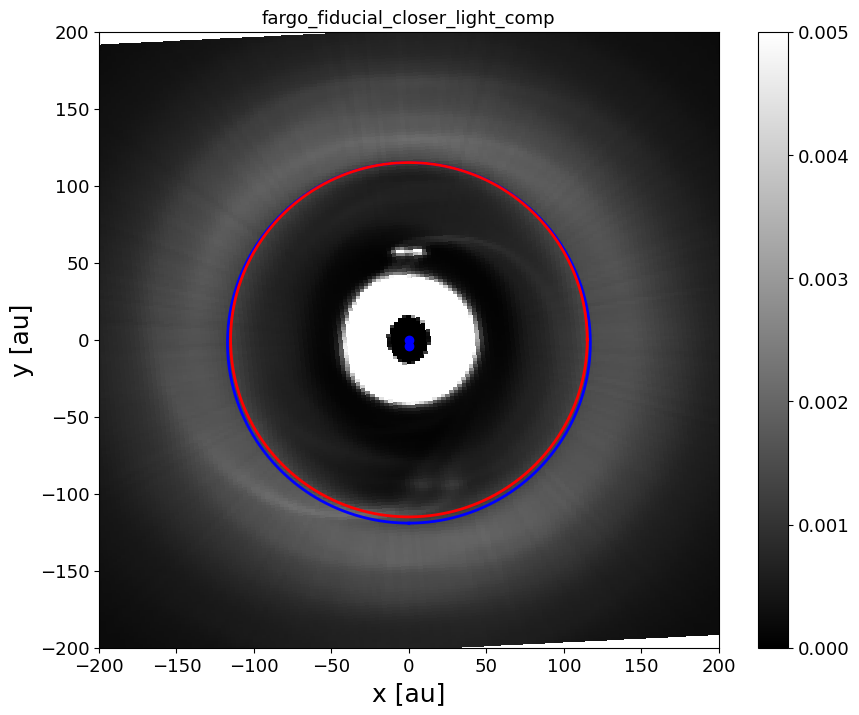

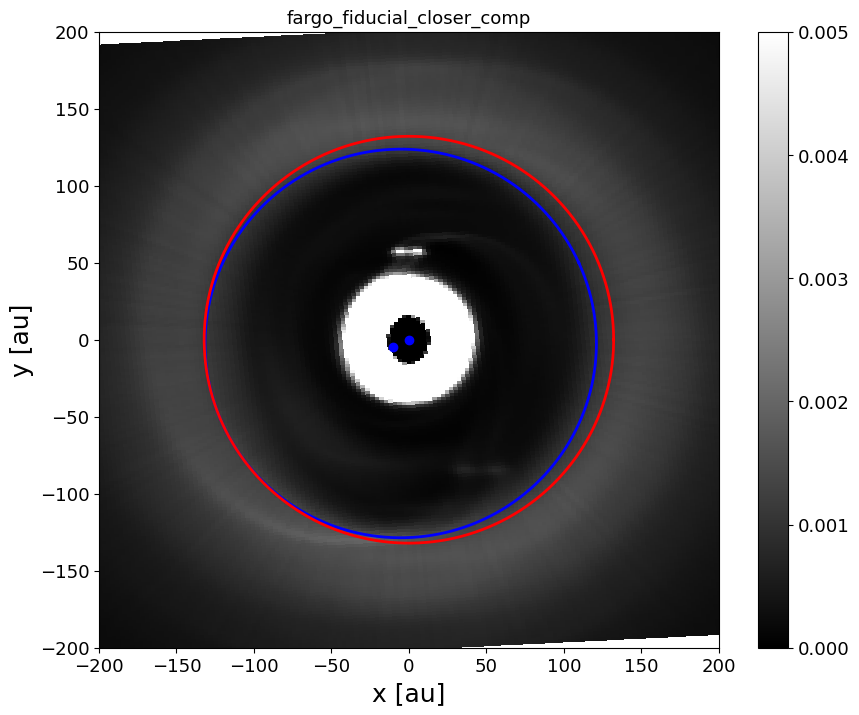

In [29]:

index_for_closer=[9,8,10]

r_in_log = [0.26,0.305,0.365]
r_out_log = [0.28,0.32,0.325]
phi_ellipse = [3,0,2]


lim = 0.003

for it, i in enumerate(index_for_closer):
    plot_deprojected(np.power(10,log_img_data[i]), clim=(0,clim_up[i])) #clim=(lim-1e-4,lim+1e-4))#
    #plot_deprojected(log_img_data[i])
    
    plt.title(paths[i][43:-5])

    r_in = np.power(10,r_in_log[it])*57
    r_out = np.power(10,r_out_log[it])*57

    a = (r_in+r_out)/2
    e = (r_out-r_in)/2
    b = np.sqrt(a**2-e**2)
    print(f"r_in: {r_in}\nr_out: {r_out}")
    path = paths[i]
    print(f"Eccentricity for {path[43:-5]}: {e/a}")
    
    centerx = e
    centery = 0
    philist = np.linspace(0,2*np.pi,360)
    
    x_ell_ = centerx + a*np.cos(philist)
    y_ell_ = centery + b*np.sin(philist)
    
    phi = phi_ellipse[it]-np.pi/2
    x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
    y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)
    
    plt.plot(x_ell,y_ell, linewidth=2, color="blue")
    plt.plot(r_in*np.cos(philist), r_in*np.sin(philist), linewidth=2, color="red", zorder=3)
    
    plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3, color="blue")

# Again, now zoomed in